PROJECT TITLE: PREDICTION OF REFERENCE EVAPOTRANSPIRATION WITH MACHINE LEARNING MODELS

DATA: The data set used in this project consists of measured hourly weather data and reference evapotranspiration calculated with the Penman-Monteith equation  
      The data set used in model training span six years: 01-01-2009 to 12-31-2014 and was obtained from AZMET: Arizona Meteorological Network web site (https://azmet.arizona.edu/azmet/14.htm)
      A description of the complete data set is provided in the data acquisition and preparation notebook  
      The final feature set used in predictive analysis of evapotranspiration consists of: 
      
      1. av_hr_ta:    Hourly average air temperature
      2. av_vap_d:    Hourly average vapor pressure deficit 
      3. tot_sol_eng: Hourly total solar energy flux per square meter 
      4. soil_temp_5: Hourly average soil temperature at 5cm depth from the surface
      5. av_wnd_spd:  Hourly average wind speed 

      and the dependent variable is 
      
      Eto: Reference evapotranspiration calculated with the Penman-Monteith equation

      The data set consists of 52608 rows by 6 columns
      
METHOD: Alternative machine learning algorithms trained with the data set are

        1. Regression Tree Model  (was used in the data preparation and analysis phase and is considered here as the base model)  
        2. Random Forest Model
        3. XGBoost Model

DATA SPLIT FOR TRAINING and TESTING: Each model was trained on 80% of the data and evaluated with 20% of the data.
                                     Data split was performed chronologically, to account for the time series nature of the data   

PERFORMANCE METRICS USED FOR MODEL EVALUATION AND SELECTION:

        1. Regression Coefficient of Determination, R²
        2. Root Mean Squared Error, mse
        3. Mean Absolute Error, mae

In addition, overfitting risk was assessed based on comparison of model's training and test phase performances  

In [3]:
#===========================
# Import required libraries
#===========================

import io                          # a python librray for handling stream-based input and output operations
import os                          # a python module for interacting with the operating system  
import requests                    # a libarary for requesting data from a website       
%matplotlib inline

# Pandas is a software library written for the Python programming language for data manipulation and analysis. Import pandas library
import pandas as pd

# NumPy is a library for the Python programming language, providing a large collection of high-level mathematical functions to operate 
# on large, multi-dimensional arrays and matrices. Import numpy library
import numpy as np

# Matplotlib is a plotting library for Python and pyplot provides us with a Matlab like plotting framework. We will use pyplot to plot data.
# import matplotlib library 
import matplotlib.pyplot as plt

# Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and 
# informative statistical graphics. Import seaborn library 
import seaborn as sns

# SKLEARN is a free open-source Python library for machine learning, predictive data modeling, and data analysis. Several sklearn functionality 
# are imported next.   

# The classes TimeSeriesSplit and GridSearchCV are imported from sklearn library providing the funcitonalities (1) to split data in chronological 
# order into training and testing data and (2) to enable GridSearch cross validation optimization during model training
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Ensemble model randomForest regression class is imported from sklearn library. It is used to fit RandomForestRegressor to the training data and to test the resultant model
from sklearn.ensemble import RandomForestRegressor

# xgboost class provides the functionality for fitting an xgboost model to the training data and testing the resultant model
from xgboost import XGBRegressor

# sklearn library provides the tools for performance metrics used in evaluation of the models 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
#====================================================================================================================
# IMPORT csv FILES FROM A WEB SITE MERGES THEIR CONTENT AND SAVES IT IN A LOCAL DRIVE AS A csv FILE. The main steps
# are summarized here:

# Import data from a web site: it is asssumed here that data is available as a CSV file and is imported sequentially 
#                              one file at a time 
# Data in each source file is read into a dataframe 
# Each dataframe is then stored/appeneded into a list of dataframes
# The contents of the list are merged into a larger dataframe
# Merged data (dataframe) is saved into a specified folder in a local drive as a CSV file
#====================================================================================================================

csv_urls = ['https://example.com', 'https://example.com']     # Create a list of strings to store the URLs from which the data files are to be extracted 
first_file_headers = None                        

# The contents of the list of URLs, "csv.urls", is defined in the exact order the files are to be imported and eventually merged into a single file:
# The following is exmaple list of URLs from AZMET (Arizona Meteorlogical Network:Yuma North Gila Station) 
# They contain hourly meteorological data and reference evapotranspiration for the years 2009 to 2014 in descending order
csv_urls = [
                'https://azmet.arizona.edu/azmet/data/1409rh.txt',
                'https://azmet.arizona.edu/azmet/data/1410rh.txt',
                'https://azmet.arizona.edu/azmet/data/1411rh.txt',
                'https://azmet.arizona.edu/azmet/data/1412rh.txt',
                'https://azmet.arizona.edu/azmet/data/1413rh.txt',
                'https://azmet.arizona.edu/azmet/data/1414rh.txt' 
            ]

# Define the local destination for the merged file
output_file_path = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\Data\TrainingAndTesting\2009_2014_Hourly.csv'

# Download csv files sequentially, import each file into a dataframe, and store each dataframe in a list as a separate block
dataframes = []                                    # Create a list called dataframes

for url in csv_urls:
  #  print(f"Downloading: {url}")
    response = requests.get(url)                    # make a request to extract data from the web site
    response.raise_for_status()                     # Ensures if request was sucessful 
    
    df = pd.read_csv(io.StringIO(response.text), header=None)    # Read the CSV content into a pandas DataFrame, df
    dataframes.append(df)                                        # Append the current data frame into the list 'dataframes' as a separate block  

# Concatenate (merge) all DataFrame blocks 
merged_df = pd.concat(dataframes, ignore_index=True)

# Save the merged dataframe in the specified directory path as a csv file (in a local drive)
merged_df.to_csv(output_file_path, index=False, header=False)

print(f"Successfully saved merged file to {output_file_path}")

In [4]:
# ====================================================================================
#  Import data, a csv, file from the local drive and read it into pandas data frame
# ====================================================================================

var_names = ['av_hr_ta', 'av_vap_d',  'av_sol_eng', 'soil_temp_5', 'av_wnd_spd', 'Eto']

output_file_path = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\TrainingAndTesting\2009_2014_Hourly.csv'
WeatherEt_df=pd.read_csv(output_file_path,names=var_names, header=0)
WeatherEt_df

,av_hr_ta,av_vap_d,av_sol_eng,soil_temp_5,av_wnd_spd,Eto
0,5.9,0.18,0.0,12.6,0.8,-0.01
1,5.7,0.18,0.0,12.3,0.3,-0.01
2,4.7,0.10,0.0,12.0,0.3,-0.02
3,3.8,0.10,0.0,11.7,0.5,-0.02
4,3.7,0.05,0.0,11.5,0.2,-0.02
...,...,...,...,...,...,...
52603,4.2,0.28,0.0,12.5,1.8,0.00
52604,3.4,0.23,0.0,11.8,0.5,-0.01
52605,1.7,0.14,0.0,11.1,0.6,-0.01
52606,1.3,0.15,0.0,10.4,1.2,-0.01


# Comment 

The dataframe, WeatherEt_df, has 52608 rows and 6 columns excluding the index column


Table: Description of Dataframe Column Names 
       
Variables              Full Name, Variable         	                   Unit           Independent vs Dependent Variables    
			
av_hr_ta	     Hourly Average Air temperature	                        oC                   Indepdent Variable   
av_vap_d	     Hourly Average Vapor Pressure Deficit	                KPa                         <<
tot_sol_eng	     Hourly Solar Energy Flux Per square meter             MJ/m2                        <<
soil_temp_5	     Hourly Average Soil Temperature at 5cm Depth	        oC                          <<
av_wnd_spd	     Hourly Average Wind Speed	                            m/s                         << 
Eto	             Hourly Reference Evapotranspiration	                mm                   Dependent Variable 

In [5]:
# Check data type of dataframe columns  

WeatherEt_df.dtypes

av_hr_ta       float64
av_vap_d       float64
av_sol_eng     float64
soil_temp_5    float64
av_wnd_spd     float64
Eto            float64
dtype: object

In [6]:
# Check if any of the dataframe columns contain entries with missing values 

WeatherEt_df.isnull().sum()

av_hr_ta       3
av_vap_d       3
av_sol_eng     3
soil_temp_5    3
av_wnd_spd     3
Eto            0
dtype: int64

# Comment 

NOTE: In the dataframe a cell with missing values were denoted by 'NULL' in the dataframe. Thus, the above result shows that each feature contains three 'NULL' values.   

In [7]:
# Handling missing data: Replace NULLs with NaNs in the dataframe, 'WeatherEt_df', delete each row that contain missing values from the dataframe, 
#                        and reset the row index of the dataframe. Ensure that rows with NULL values are removed from the dataframe

WeatherEt_df = WeatherEt_df.replace('NULL', np.nan)
WeatherEt_df.dropna(inplace=True)
WeatherEt_df.reset_index(drop=True, inplace=True)
WeatherEt_df.isnull().sum()

av_hr_ta       0
av_vap_d       0
av_sol_eng     0
soil_temp_5    0
av_wnd_spd     0
Eto            0
dtype: int64

In [8]:
# Ensure that the dataframe column header strings do not contain extra hidden characters. 
# Ensure consistency between teh list 'var_names' and column headings of the imported data

WeatherEt_df.columns

Index(['av_hr_ta', 'av_vap_d', 'av_sol_eng', 'soil_temp_5', 'av_wnd_spd',
       'Eto'],
      dtype='object')

In [9]:
#==========================================================================================
# PPREDICTIVE ANALYSIS WITH MACHINE LEARNING:
# THREE MACHINE LEARNING MODELS WILL BE TRAINED WITH THE DATA AND THE BEST PERFORMING
# MODEL WILL BE SELECTED FOR FURTHER EVALUATION BASED ON UNSEEN DATA
# THE MODELS ARE:
#    - REGRESSION TREE
#    - RANDOMFOREST
#    - XGBOOST
#    
# THE PERFORMANCE METRIC USED ARE:
#   - COEFFICIENT OF DETERMINATION, R^2, USED BOTH IN TRAINING AND TESTING
#   - MEAN SQUARED ERROR, MSE, USED IN TESTING
#   - MEAN ABSOLUTE ERROR, MAE, USED IN TESTING
#==========================================================================================

# Additional imports required for the new model
from sklearn.tree import DecisionTreeRegressor

#=======================================
# PREPARE DATA FOR MODELING
#=======================================

# Define feature set and depdendent variable 
X = WeatherEt_df[['av_hr_ta', 'av_vap_d', 'av_sol_eng', 'soil_temp_5', 'av_wnd_spd']]
dep_v = WeatherEt_df['Eto']

# Split Data for Machine learning. Use Chronological Train/Test Split (80% Train / 20% Test)
# a method suited for time series data
n_samples = len(WeatherEt_df)
test_size = int(n_samples * 0.2)
split_index = n_samples - test_size

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
dep_v_train, dep_v_test = dep_v.iloc[:split_index].copy(), dep_v.iloc[split_index:]

av_Eto_train = np.mean(dep_v_train)
av_Eto_test = av_Eto = np.mean(dep_v_test)

# Initialize Cross-Validation Generator
tscv = TimeSeriesSplit(n_splits=5)


# =====================================================================
# OPTIMIZE MODEL 1: DECISION TREE REGRESSOR
# =====================================================================
print("\n--- Tuning Decision Tree Model ---")

# Define the parameter grid for the Decision Tree model
dt_grid = {
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [5, 10, 15, 20],
                'min_samples_leaf': [1, 2, 4]
           }

# Define a Decision Tree object and initialize it
dt_search = GridSearchCV(
                            estimator=DecisionTreeRegressor(random_state=42),
                            param_grid=dt_grid,
                            cv=tscv,
                            scoring='r2',
                            n_jobs=-1
                        )

# Fit the Decision Tree model to the training data
dt_search.fit(X_train, dep_v_train)
best_dt = dt_search.best_estimator_

# Get predictions of the optimized regression tree model based on the training data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_train_pred = best_dt.predict(X_train)
dt_train_metrics ={
                       'r2' : r2_score(dep_v_train, dep_v_train_pred),
                       'mse' : mean_squared_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100,
                       'mae' : mean_absolute_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100                      
                   }

# Get predictions of the optimized regression tree model based on the test data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_pred_dt = best_dt.predict(X_test)
dt_test_metrics = {
                        'r2': r2_score(dep_v_test, dep_v_pred_dt),
                        'mse': mean_squared_error(dep_v_test, dep_v_pred_dt)/av_Eto_test * 100,
                        'mae': mean_absolute_error(dep_v_test, dep_v_pred_dt)/av_Eto_test * 100                       
                    }


# =====================================================================
# OPTIMIZE MODEL 2: RANDOM FOREST (rf)
# =====================================================================
print("--- Tuning Random Forest Model ---")

# Define a parameter grid for the RandomForest model
rf_grid = {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 15, None],
                'min_samples_split': [2, 5]
          }

# Define the RandomForest object and intialize it 
rf_search = GridSearchCV(
                            estimator=RandomForestRegressor(random_state=42),
                            param_grid=rf_grid,
                            cv=tscv,
                            scoring='r2',
                            n_jobs=-1
                        )

# Fit the RandomForest model to the training data
rf_search.fit(X_train, dep_v_train)
best_rf = rf_search.best_estimator_

# Get predictions of the optimized Random Forest Regression model based on the training data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_train_pred = best_rf.predict(X_train)
rf_train_metrics ={
                       'r2' : r2_score(dep_v_train, dep_v_train_pred),
                       'mse' : mean_squared_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100,
                       'mae' : mean_absolute_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100                     
                   }


# Get predictions of the optimized Random Forest Regression model based on the test data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_pred_rf = best_rf.predict(X_test)
rf_test_metrics = {
                       'r2': r2_score(dep_v_test, dep_v_pred_rf),
                       'mse': mean_squared_error(dep_v_test, dep_v_pred_rf)/av_Eto_test * 100,
                       'mae': mean_absolute_error(dep_v_test, dep_v_pred_rf)/av_Eto_test * 100
                  }

# =====================================================================
# OPTIMIZE MODEL 3: XGBOOST
# =====================================================================
print("--- Tuning XGBoost Base Model ---")

# Define a parameter grid for xgboost model
xgb_grid = {
                'n_estimators': [100, 200, 300],
                'learning_rate': [0.05, 0.1],
                'max_depth': [4, 6, 8]
            }

# Define an xgboost object, xgboost_search, and intialzie it
xgb_search = GridSearchCV(
                            estimator=XGBRegressor(random_state=42),
                            param_grid=xgb_grid,
                            cv=tscv,
                            scoring='r2',
                            n_jobs=-1
                        )

# Fit the xgboost model to the training data
xgb_search.fit(X_train, dep_v_train)
best_xgb = xgb_search.best_estimator_

# Get predictions of the optimized XGBoost Regression model based on the training data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_train_pred = best_xgb.predict(X_train)
xgb_train_metrics ={
                       'r2' : r2_score(dep_v_train, dep_v_train_pred),
                       'mse' : mean_squared_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100,
                       'mae' : mean_absolute_error(dep_v_train, dep_v_train_pred)/av_Eto_train * 100
                   }

# Get predictions of the optimized XGBoost Regression model based on the test data set, 
# determine the corresponding performance metrics, and store the results in a dictionary 
dep_v_pred_xgb = best_xgb.predict(X_test)
xgb_test_metrics = {
                        'r2': r2_score(dep_v_test, dep_v_pred_xgb),
                        'mse': mean_squared_error(dep_v_test, dep_v_pred_xgb)/av_Eto_test * 100,
                        'mae': mean_absolute_error(dep_v_test, dep_v_pred_xgb)/av_Eto_test * 100
                     }

# =====================================================================
# FINAL REPORT COMPARISON
# =====================================================================

print("\n" + "=" * 65)
print(" MODEL PERFORMANCE COMPARISON ")
print("=" * 65)
print(f"{'Metric':<20} | {'Decision Tree':<15} | {'Random Forest':<15} | {'XGBoost':<15}")
print("-" * 69)
print(f"{'R² Score':<20} | {dt_train_metrics['r2']:<15.4f} | {rf_train_metrics['r2']:<15.4f} | {xgb_train_metrics['r2']:<15.4f}")
print(f"{'Percent RMSE (%)':<20} | {dt_train_metrics['mse']:<15.4f} | {rf_train_metrics['mse']:<15.4f} | {xgb_train_metrics['mse']:<15.4f}")
print(f"{'Percent MAE (%)':<20} | {dt_train_metrics['mae']:<15.4f} | {rf_train_metrics['mae']:<15.4f} | {xgb_train_metrics['mae']:<15.4f}")
print("-" * 69)
print(f"{'R² Score':<20} | {dt_test_metrics['r2']:<15.4f} | {rf_test_metrics['r2']:<15.4f} | {xgb_test_metrics['r2']:<15.4f}")
print(f"{'Percent RMSE (%)':<20} | {dt_test_metrics['mse']:<15.4f} | {rf_test_metrics['mse']:<15.4f} | {xgb_test_metrics['mse']:<15.4f}")
print(f"{'Percent MAE (%)':<20} | {dt_test_metrics['mae']:<15.4f} | {rf_test_metrics['mae']:<15.4f} | {xgb_test_metrics['mae']:<15.4f}")
print("=" * 69)
print(f"{'The training and test RMSE and MSE values are percentages of the respective average reference evapotranspiration depths:'} ")
print(f"{'Average reference evapotranspiration, training phase (mm)     ':<15} | {av_Eto_train:<15.4f} ")
print(f"{'Average reference evapotranspiration (Eto), testing phase (mm)':<15} | {av_Eto_test:<15.4f} ")


--- Tuning Decision Tree Model ---
--- Tuning Random Forest Model ---
--- Tuning XGBoost Base Model ---

 MODEL PERFORMANCE COMPARISON 
Metric               | Decision Tree   | Random Forest   | XGBoost        
---------------------------------------------------------------------
R² Score             | 0.9998          | 0.9999          | 0.9997         
Percent RMSE (%)     | 0.0080          | 0.0033          | 0.0094         
Percent MAE (%)      | 0.9239          | 0.6719          | 1.4777         
---------------------------------------------------------------------
R² Score             | 0.9979          | 0.9993          | 0.9995         
Percent RMSE (%)     | 0.0724          | 0.0231          | 0.0169         
Percent MAE (%)      | 3.3353          | 1.8822          | 2.0009         
The training and test RMSE and MSE values are percentages of the respective average reference evapotranspiration depths: 
Average reference evapotranspiration, training phase (mm)      | 0.2376     

# Comparison of Model Performance and Model Selection 


Note: Model performance on the training and test sets was evaluated in terms of the following metrics: 
      - Regression coefficient of determination, R²
      - Percent Root Mean Squared Error, PRME, which is the RMSE expressed as a percentage of the average observed reference evapotranspiration
      - Percent Mean Absolute Error, PMAE, which is the MAE expressed as a percentage of the average observed reference evapotranspiration
    

# Training phase performance:

- Coefficient of determination, R², values are very high for all the models =>0.999. The highest R² value was 0.9999 and was observed for
  the Random Forest model, rf. The smallest R² values was 0.9997 and was obtained for the XGBoost model, xgb
  
- Percent root mean squared error (PRMSE) for each model is less than 0.01%. The smallest PRMSE of 0.0033% was observed for the rf model
  and the highest PRMSE of 0.0094% was obtained for the xgb model
  
- The maximum percent mean absolute error (PMAE) is 1.48% and was observed for the xgb model, while the lowest PMAE of 0.67% was obtained
  for the rf model
  
- Overall, the performance of all the three models on the training set is excellent (optimization R² > 0.999, PMSE < 0.01%, and PMAE < 1.5%).
  However, with a training phase R² of about 1.0 and with the lowest PRMSE (of 0.0033%) and PMAE (of 0.0672%), the random forest model appears
  to have marginally outperformed the decsision tree regresser, dt, and xgb models 

# Testing phase performance: 

- Testing phase R² values are very high for all the models =>0.997. The highest test phase R² value was 0.9995 and was observed for the xgb
  model. The smallest R² values was 0.9979 and was obtained for the dt model
  
- The maximum testing phase PRMSE is 0.072% and was obtained for the dt model. The lowest PRMSE of 0.017% and was observed for the xgb model.
  Overall, the PRMSE data shows that the alternative models are of comparable accuracy.
 
- The maximum percent absolute error is 3.34% and was observed for the dt model, while the lowest PMAE of 1.88% was obtained for the rf 
  model. With PMAE of 2.0% the xgb model falls in between. 

- Overall, all the three models appear to have comparably good performance in so far as testing phase R² (> 0.997) and PRMSE (< 0.08%) are  
  concerned

- By contrast, with a testing phase PMAE of 3.34%, the dt model appears to have noticeably underperformed both the rf (PMAE = 1.88%) and xgb
  (PMAE = 2.0%) models. 
 
# Overfitting consideration 

- The exceptionally high optimization phase R² attained by each model is not necessarily the result of overfitting. The models were trained on
  data where the dependent variable column, 'Eto', was generated by physics based deterministic model (i.e., the Penman-Monteith equation). As
  result, the Eto data are free from random "noise" that could have contributed to overfitting. This suggests that the very high R² values by
  themselves do not imply the existence of overfitting.
  
- The fact that, for each model, the decline in R² values from the training to the test phase are marginal (test phase R² values are within 0.2%
  of the training phase R²) suggests that the R² data do not point to appreciable risk of overfitting for any of the alternative models
 
- By comparison, however, for each of the models, the test phase PRMSE and PMAE increased by appreciable amounts relative to those of the training
  phase PRMSE and PMAE data. Test phase PRMSE rose by a minimum of 79.8% (xgb model) and a maximum of 805% (dt model) compared to the respective
  training phase PRMSE values. On the other hand, the test phase PMAE increased by a minimum of 35.4% (xgb model) and a maximum of 261% (dt model)
  from the respective optimization phase PMAE values. These results suggest that each of the alternative models may carry some risk of overfitting.
  In addition, the results show that among the alternative models, the xgb model has the least risk of overfitting, while the dt model has the highest
  potential for overfitting.
    
# Conclusion: 

- Considering time limitations we will, at this point, end model development and proceed to model selection. 
 
- The performance data and the preceding discussion indicates that, on the test set, the random forest and XGBoost models slightly outperformed 
  the decision tree regresser model. Additionally, the dt model appears to carry the highest risk of over fitting among the alternative models.

- The test phase performance of the xgb model is slightly better than that of the rf model. The xgb and rf models have about the same R², but 
  the PRMSE of the rf model exceeds that of the xgb model by about 40%, while the MAE of the xgb model exceeds that of the rf model by about 6%.

- The test phase versus optimization phase PRMSE and PMAE data suggest that the xgb model has a slightly lower risk of overfitting compared to the
  rf model and, hence, a better capability to abstract true trends in the training set

- Furthermore, the xgb model is considered the machine learning industry standard for regression and classification modeling 
   
- Overall, the xgb model appears to have slight edge over the rf model. Thus, the xgb model is selected here as the preferred model and will be carried 
  forward to the next phase of the current project, which involves evaluation of the predictive performance of the xgb model using different sets of 
  completely unseen data. 


--- Processing Decision Tree ---


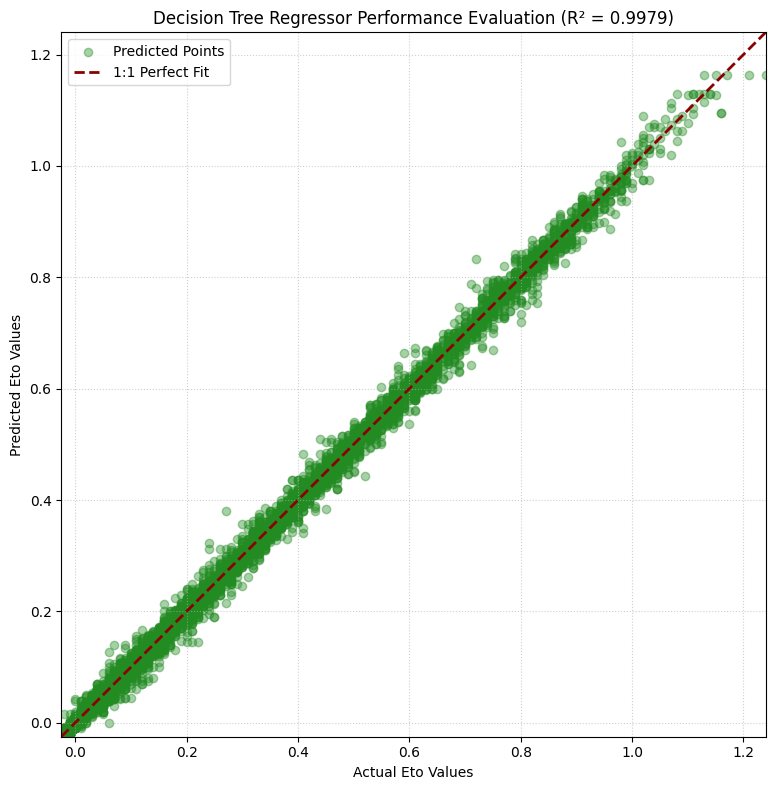

Decision Tree saved at: C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\TrainingAndTesting\optimized_decision_tree_reg_eto.joblib

--- Processing Random Forest ---


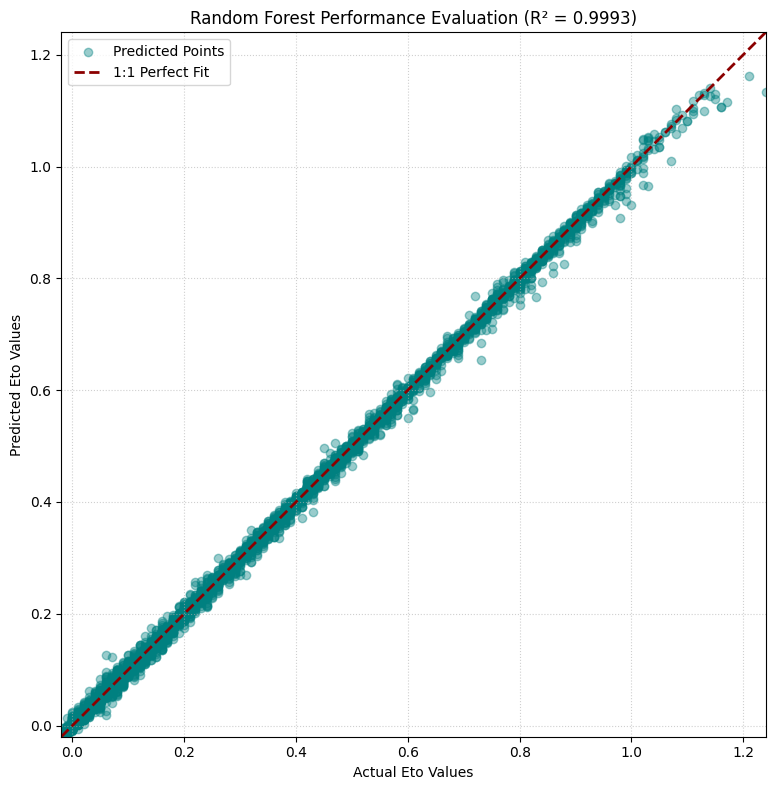

Random Forest saved at: C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\TrainingAndTesting\optimized_random_forest_eto.joblib

--- Processing XGBoost ---


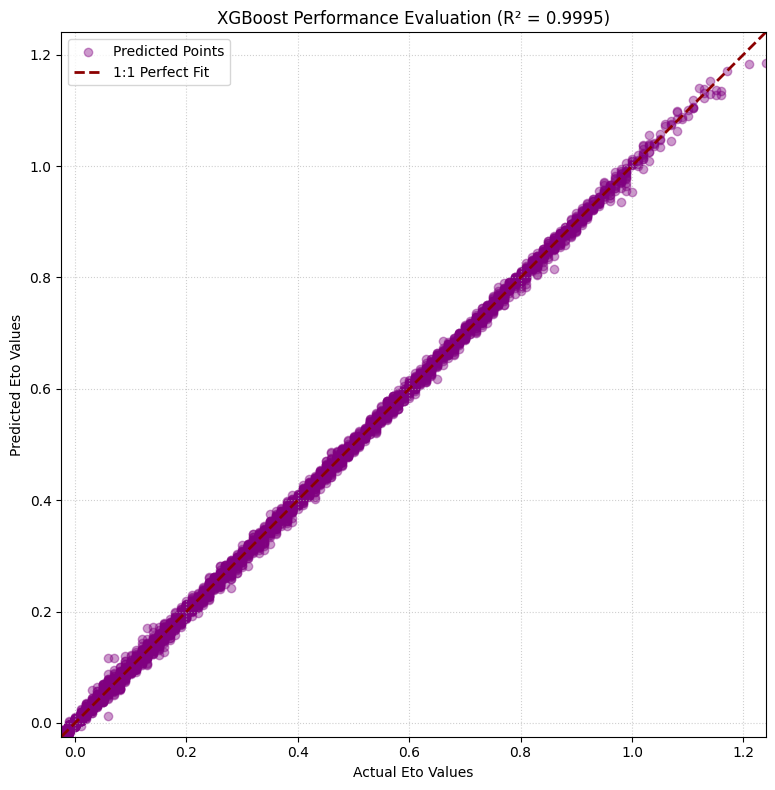

XGBoost saved at: C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\TrainingAndTesting\optimized_xgboost_eto.joblib


In [15]:
# The relative importance of the features within the framework of each candicate model is evaluated here 

import joblib
from sklearn.inspection import permutation_importance

# Specify directory path to save the output files
output_dir = os.path.dirname(output_file_path)
                   
# =====================================================================
# BLOCK 1: DECISION TREE REGRESSOR (DT) ANALYSIS
# =====================================================================
print("\n--- Processing Decision Tree ---")

# Plot Actual vs. Predicted 1:1 Chart
plt.figure(figsize=(8, 8))
# Scatter plot 
plt.scatter(dep_v_test, dep_v_pred_dt, alpha=0.4, color='forestgreen', label='Predicted Points')                                        
min_val = min(min(dep_v_test), min(dep_v_pred_dt))
max_val = max(max(dep_v_test), max(dep_v_pred_dt))   
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='1:1 Perfect Fit')                             
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Actual Eto Values')
plt.ylabel('Predicted Eto Values')
plt.title(f'Decision Tree Regressor Performance Evaluation (R² = {dt_test_metrics["r2"]:.4f})')                                                   
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eto_actual_vs_predicted_dt.png'), dpi=300)                                                         
plt.show()

# Save Model
model_save_path_dt = os.path.join(output_dir, 'optimized_decision_tree_reg_eto.joblib')                                                     
joblib.dump(best_dt, model_save_path_dt)
print(f"Decision Tree saved at: {model_save_path_dt}")

# =====================================================================
# BLOCK 2: RANDOM FOREST (RF) ANALYSIS
# =====================================================================
print("\n--- Processing Random Forest ---")

# Plot Actual vs. Predicted 1:1 Chart
plt.figure(figsize=(8, 8))
plt.scatter(dep_v_test, dep_v_pred_rf, alpha=0.4, color='teal', label='Predicted Points')
min_val = min(min(dep_v_test), min(dep_v_pred_rf))
max_val = max(max(dep_v_test), max(dep_v_pred_rf))
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='1:1 Perfect Fit')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Actual Eto Values')
plt.ylabel('Predicted Eto Values')
plt.title(f'Random Forest Performance Evaluation (R² = {rf_test_metrics["r2"]:.4f})')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eto_actual_vs_predicted_rf.png'), dpi=300)
plt.show()

# Save Model
model_save_path_rf = os.path.join(output_dir, 'optimized_random_forest_eto.joblib')
joblib.dump(best_rf, model_save_path_rf)
print(f"Random Forest saved at: {model_save_path_rf}")


# =====================================================================
# BLOCK 3: XGBOOST (XGB) ANALYSIS
# =====================================================================
print("\n--- Processing XGBoost ---")

# Plot Actual vs. Predicted 1:1 Chart
plt.figure(figsize=(8, 8))
plt.scatter(dep_v_test, dep_v_pred_xgb, alpha=0.4, color='purple', label='Predicted Points')
min_val = min(min(dep_v_test), min(dep_v_pred_xgb))
max_val = max(max(dep_v_test), max(dep_v_pred_xgb))
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='1:1 Perfect Fit')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Actual Eto Values')
plt.ylabel('Predicted Eto Values')
plt.title(f'XGBoost Performance Evaluation (R² = {xgb_test_metrics["r2"]:.4f})')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'eto_actual_vs_predicted_xgb.png'), dpi=300)
plt.show()

# Save Model
model_save_path_xgb = os.path.join(output_dir, 'optimized_xgboost_eto.joblib')
joblib.dump(best_xgb, model_save_path_xgb)
print(f"XGBoost saved at: {model_save_path_xgb}")

# Comment: Comparison of Model Predicted and Observed Evapotranspiration

- The above charts provide a graphic depiction of the goodness of fit of each model's prediction of reference evapotranspiration, which evidently concurs with the model perfromance data 
  shown ealrier 
- The chart for the XGBoost model shows that the data points are tightly packed about the regression line, while data points associated with the Decision Tree Regressor model show greater
  spread about the regresion line. For the random forest model, the level of data spread about the regression line falls in between the other two models. 